In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from visualization.utils import AgentMetrics, get_training_progress, display_training_progress

In [2]:
training_progress_gnn_baseline: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/baselines/ppo/logs_baselines_ppo_gnn_2025-12-01_19-13-27_1.csv"), "GNN-Baseline")
training_progress_mlp_baseline: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/baselines/ppo/logs_baselines_ppo_mlp_2025-12-01_16-23-20_1.csv"), "MLP-Baseline")

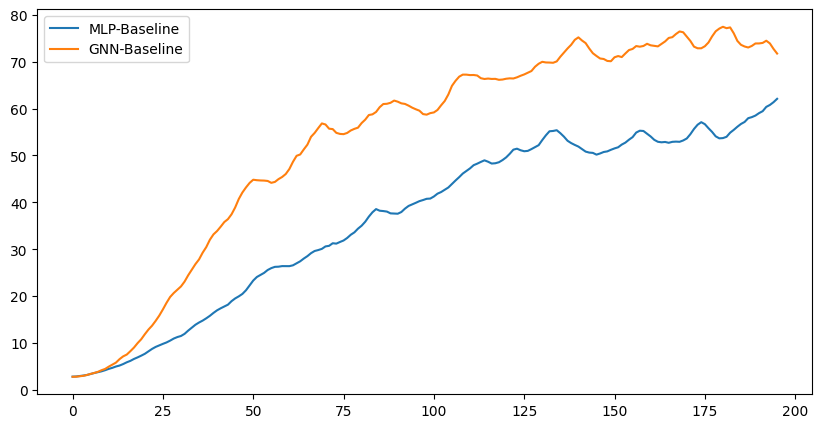

In [3]:
_ = display_training_progress([training_progress_mlp_baseline, training_progress_gnn_baseline])

In [4]:
rappo_1_0: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-11-29_15-16-13_1.csv"), "1.0")
rappo_0_9: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-11-30_20-59-19_0.9_1.csv"), "0.9")
rappo_0_8: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-11-30_00-00-14_0.8_1.csv"), "0.8")
rappo_0_7: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-12-01_13-14-55_0.7_1.csv"), "0.7")
rappo_0_6: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-11-30_12-13-36_0.6_1.csv"), "0.6")
rappo_0_5: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-12-01_19-27-52_0.5_1.csv"), "0.5")
rappo_0_4: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-11-30_18-52-09_0.4_1.csv"), "0.4")
rappo_0_3: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-12-01_23-07-35_0.3_1.csv"), "0.3")
rappo_0_2: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-11-30_22-50-31_0.2_1.csv"), "0.2")
rappo_0_1: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-12-02_02-44-14_0.1_1.csv"), "0.1")
rappo_0_0: AgentMetrics = get_training_progress(Path("../data/experiments/compare_ppo_local/logs/relation-aware/ppo/graphormer/logs_relation-aware_ppo_graphormer_rappo_2025-12-01_08-39-31_0.0_1.csv"), "0.0")

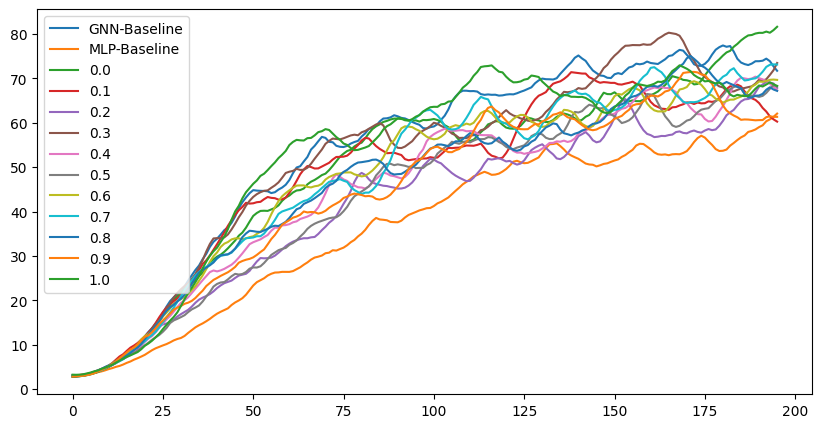

In [5]:
_ = display_training_progress([training_progress_gnn_baseline, training_progress_mlp_baseline, rappo_0_0, rappo_0_1, rappo_0_2, rappo_0_3, rappo_0_4, rappo_0_5, rappo_0_6, rappo_0_7, rappo_0_8, rappo_0_9, rappo_1_0])

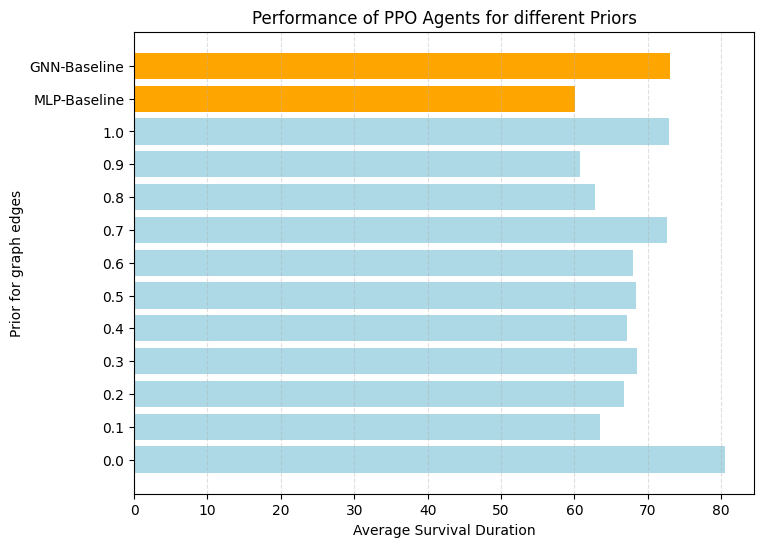

In [6]:
metrics = [rappo_0_0, rappo_0_1, rappo_0_2, rappo_0_3, rappo_0_4, rappo_0_5, rappo_0_6, rappo_0_7, rappo_0_8, rappo_0_9, rappo_1_0]
average_last_25 = [(sum(metric.survival_duration[-25:])/25, metric.label) for metric in metrics]
baseline_average_last_25 = [(sum(metric.survival_duration[-25:])/25, metric.label) for metric in [training_progress_mlp_baseline, training_progress_gnn_baseline]]

values = [v for v, _ in average_last_25] + [v for v, _ in baseline_average_last_25]
names  = [n for _, n in average_last_25] + [n for _, n in baseline_average_last_25]
colors = ["lightblue" for _ in average_last_25] + ["orange" for _ in baseline_average_last_25]

plt.figure(figsize=(8, 6))
plt.barh(names, values, color=colors)
plt.xlabel("Average Survival Duration")
plt.ylabel("Prior for graph edges")
plt.title("Performance of PPO Agents for different Priors")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

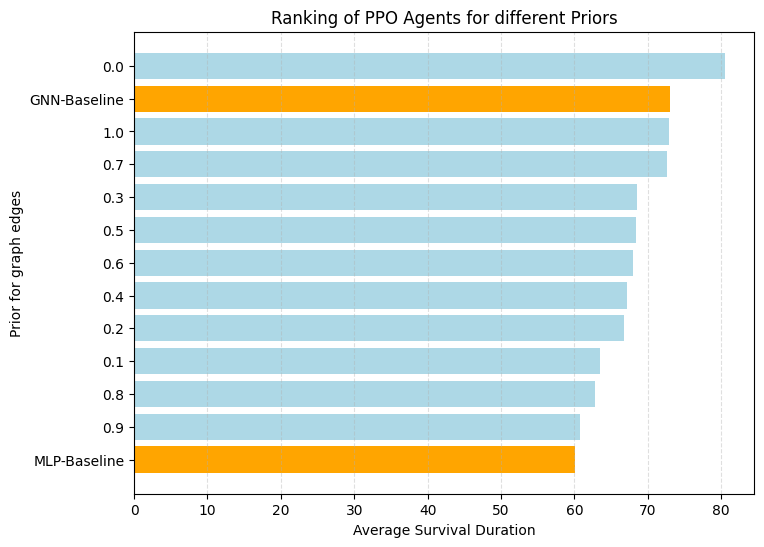

In [7]:
rappo_and_baseline = list(zip(values, names, colors))
rappo_and_baseline.sort(reverse=True, key=lambda x: x[0])

plt.figure(figsize=(8, 6))
for i in range(len(rappo_and_baseline)):
    plt.barh(rappo_and_baseline[i][1], rappo_and_baseline[i][0], color=rappo_and_baseline[i][2])
plt.gca().invert_yaxis()  # highest rank on top
plt.xlabel("Average Survival Duration")
plt.ylabel("Prior for graph edges")
plt.title("Ranking of PPO Agents for different Priors")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()